In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loding the reduced dataset 
bank_reduced_df = pd.read_csv('../bank_marketing_reduced.csv')

# Data Dictionary

## Transformed Dataset

|   | Variable | Type | Pandas dtype | Description | |
|---|---|---|---|---|---|
| 1 | `age` | Numeric | `float64` | Age of the client (missing values imputed by job group median) | Original Variable |
| 2 | `job` | Categorical | `string` | Type of job (missing values imputed with mode) | Original Variable |
| 3 | `marital` | Categorical | `string` | Marital status | Original Variable |
| 4 | `education` | Categorical | `string` | Highest level of education (missing values imputed with mode) | Original Variable |
| 5 | `default` | Binary | `string` | Whether the client has credit in default (missing values imputed with mode) | Original Variable |
| 6 | `balance` | Numeric | `int64` | Average yearly balance in euros | Original Variable |
| 7 | `housing` | Binary | `string` | Whether the client has a housing loan | Original Variable |
| 8 | `loan` | Binary | `string` | Whether the client has a personal loan | Original Variable |
| 9 | `contact` | Categorical | `string` | Communication type used to contact the client (filled with "missing") | Original Variable |
| 10 | `day` | Numeric | `int64` | Last contact day of the month | Original Variable |
| 11 | `month` | Categorical | `string` | Last contact month of the year (variabled droped in reduced dataset, replaced by `month_num` ) | Original Variable |
| 12 | `duration` | Numeric | `int64` | Last contact duration in seconds | Original Variable |
| 13 | `campaign` | Numeric | `int64` | Number of contacts made during this campaign | Original Variable |
| 14 | `pdays` | Numeric | `int64` | Days since last contact from previous campaign -1 means never contacted (variable droped in reduced dataset) | Original Variable |
| 15 | `previous` | Numeric | `int64` | Number of contacts made before this campaign | Original Variable |
| 16 | `poutcome` | Categorical | `string` | Outcome of the previous marketing campaign ("unknown" filled with "missing") | Original Variable |
| 17 | `deposit` | Binary | `string` | Whether client subscribed to a term deposit | Original Variable |
| 18 | `job_was_unknown` | Binary | `int64` | 1 if `job` was originally `"unknown"` | Indicator Variable |
| 19 | `education_was_unknown` | Binary | `int64` | 1 if `education` was originally `"unknown"` | Indicator Variable |
| 20 | `contact_was_unknown` | Binary | `int64` | 1 if `contact` was originally `"unknown"` | Indicator Variables |
| 21 | `poutcome_was_unknown` | Binary | `int64` | 1 if `poutcome` was originally `"unknown"` | Indicator Variable |
| 22 | `was_previously_contacted` | Binary | `int64` | 1 if client was contacted before this campaign | Transformed Feature |
| 23 | `effective_pdays` | Numeric | `float64` | Days since last contact from previous campaign (NaN if never contacted) | Transformed Feature |
| 24 | `balance_per_contact` | Numeric | `float64` | Average yearly balance divided by number of campaign contacts | Transformed Feature |
| 25 | `duration_per_contact` | Numeric | `float64` | Last contact duration divided by number of campaign contacts | Transformed Feature |
| 26 | `has_any_loan` | Binary | `int64` | 1 if client has either a housing or personal loan, 0 for neither | Transformed Feature |
| 27 | `month_num` | Numeric | `Int64` | Month of last contact as a number (1 = Jan, 12 = Dec) | Transformed Feature |
| 28 | `quarter` | Categorical | `category` | Quarter of last contact derived from month (q1, q2, q3, q4) | Transformed Feature |
| 29 | `age_group` | Categorical | `category` | Age grouped (18-25, 26-35, 36-50, 51-65, 65+) | Transformed Feature |
| 30 | `balance_band` | Categorical | `category` | Balance grouped into quartile bands (low, medium, high, very_high) | Transformed Feature |
| 31 | `campaign_band` | Categorical | `category` | Campaign contacts grouped into frequency bands (1_contact, 2_to_3, 4_to_6, 7_plus) | Transformed Feature |
| 32 | `age_minmax` | Numeric | `float64` | Age scaled to 0–1 range | Min-Max Normalization |
| 33 | `balance_minmax` | Numeric | `float64` | Balance scaled to 0–1 range | Min-Max Normalization |
| 34 | `day_minmax` | Numeric | `float64` | Day scaled to 0–1 range | Min-Max Normalization |
| 35 | `duration_minmax` | Numeric | `float64` | Duration scaled to 0–1 range | Min-Max Normalization |
| 36 | `campaign_minmax` | Numeric | `float64` | Campaign contacts scaled to 0–1 range | Min-Max Normalization |
| 37 | `previous_minmax` | Numeric | `float64` | Previous contacts scaled to 0–1 range | Min-Max Normalization |
| 38 | `balance_per_contact_minmax` | Numeric | `float64` | Balance per contact scaled to 0–1 range | Min-Max Normalization |
| 39 | `duration_per_contact_minmax` | Numeric | `float64` | Duration per contact scaled to 0–1 range | Min-Max Normalization | 



**The reduced dataset, consisting of 37 variables, will be used for data analysis and visualization. The transformed dataset contains 39 variables, while the reduced dataset excludes `month` and `pdays`.**


# Exploratory Data Analysis

In this section we explore the distribution of each feature and its relationship with the target variable `deposit`. This will helps us understand the data before modeling.

In [3]:
bank_reduced_df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,...,balance_band,campaign_band,age_minmax,balance_minmax,day_minmax,duration_minmax,campaign_minmax,previous_minmax,balance_per_contact_minmax,duration_per_contact_minmax
0,58.0,management,married,tertiary,no,2143,yes,no,missing,5,...,very_high,1_contact,0.519481,0.092259,0.133333,0.053070,0.0,0.0,0.082497,0.053070
1,44.0,technician,single,secondary,no,29,yes,no,missing,5,...,low,1_contact,0.337662,0.073067,0.133333,0.030704,0.0,0.0,0.063098,0.030704
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,missing,5,...,low,1_contact,0.194805,0.072822,0.133333,0.015453,0.0,0.0,0.062850,0.015453
3,47.0,blue-collar,married,secondary,no,1506,yes,no,missing,5,...,very_high,1_contact,0.376623,0.086476,0.133333,0.018707,0.0,0.0,0.076651,0.018707
4,39.0,blue-collar,single,secondary,no,1,no,no,missing,5,...,low,1_contact,0.272727,0.072812,0.133333,0.040260,0.0,0.0,0.062841,0.040260


In [4]:
bank_reduced_df.shape

(45211, 37)

In [5]:
bank_reduced_df.dtypes

age                            float64
job                                str
marital                            str
education                          str
default                            str
balance                          int64
housing                            str
loan                               str
contact                            str
day                              int64
duration                         int64
campaign                         int64
previous                         int64
poutcome                           str
deposit                            str
job_was_unknown                  int64
education_was_unknown            int64
contact_was_unknown              int64
poutcome_was_unknown             int64
was_previously_contacted         int64
effective_pdays                float64
balance_per_contact            float64
duration_per_contact           float64
has_any_loan                     int64
month_num                        int64
quarter                  

In [6]:
string_variables = bank_reduced_df.select_dtypes(include = ['str']).columns.tolist()
string_variables

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'poutcome',
 'deposit',
 'quarter',
 'age_group',
 'balance_band',
 'campaign_band']

In [7]:
bank_reduced_df[string_variables] = bank_reduced_df[string_variables].astype('category')

## Target Variable

The target variable in this analysis is `deposit`, a binary variable indicating whether a client subscribed to a term deposit following a phone marketing campaign.

In [8]:
sns.set_style('whitegrid')

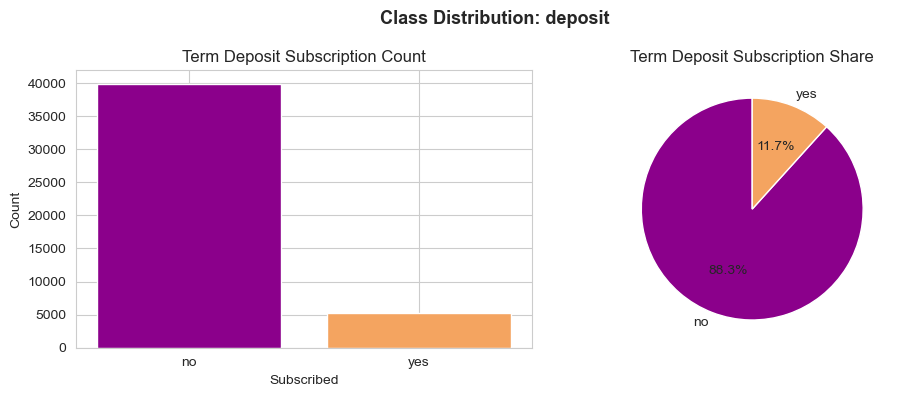

,deposit,count
0,no,39922
1,yes,5289


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

deposit_counts = bank_reduced_df['deposit'].value_counts()

axes[0].bar(deposit_counts.index, deposit_counts.values, color= ['darkmagenta', 'sandybrown'])
# axes[0].bar(deposit_counts.index, deposit_counts.values, color= ['darkviolet', 'darkorange'])
axes[0].set_title('Term Deposit Subscription Count')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')

axes[1].pie(deposit_counts.values, labels=deposit_counts.index,
            # autopct='%1.1f%%', colors=['darkviolet', 'darkorange'], startangle=90)
            autopct='%1.1f%%', colors=['darkmagenta', 'sandybrown'], startangle=90)
axes[1].set_title('Term Deposit Subscription Share')

plt.suptitle('Class Distribution: deposit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deposit_chart.png')
plt.show()

deposit_counts.reset_index()

### Findings

The target variable is `deposit`, a binary variable indicating whether a client subscribed to a term deposit following a phone marketing campaign. A term deposit is a fixed-term savings product where a customer agrees to deposit a sum of money for a set period in exchange for a guaranteed interest rate. From the bank's perspective, identifying clients who are likely to subscribe is valuable because it enables targeted marketing efforts on the most promising leads, lowering campaign costs and increasing subscriptions. 

The dataset is heavily imbalanced, with 88.3% of clients not subscribing (39,922 records) and only 11.7% subscribing (5,289 records). This kind of imbalance is common in marketing datasets, as most contacted clients will typically decline an offer, regardless of how well targeted the campaign is. However, it poses a challenge for modeling, since a model that predicts “no” for all cases might appear highly accurate but has no meaningful predictive power. Because of this, handling class imbalance is a key consideration throughout the modeling process.


## Numerical Variables
The chart below shows the distribution of all numerical variables.

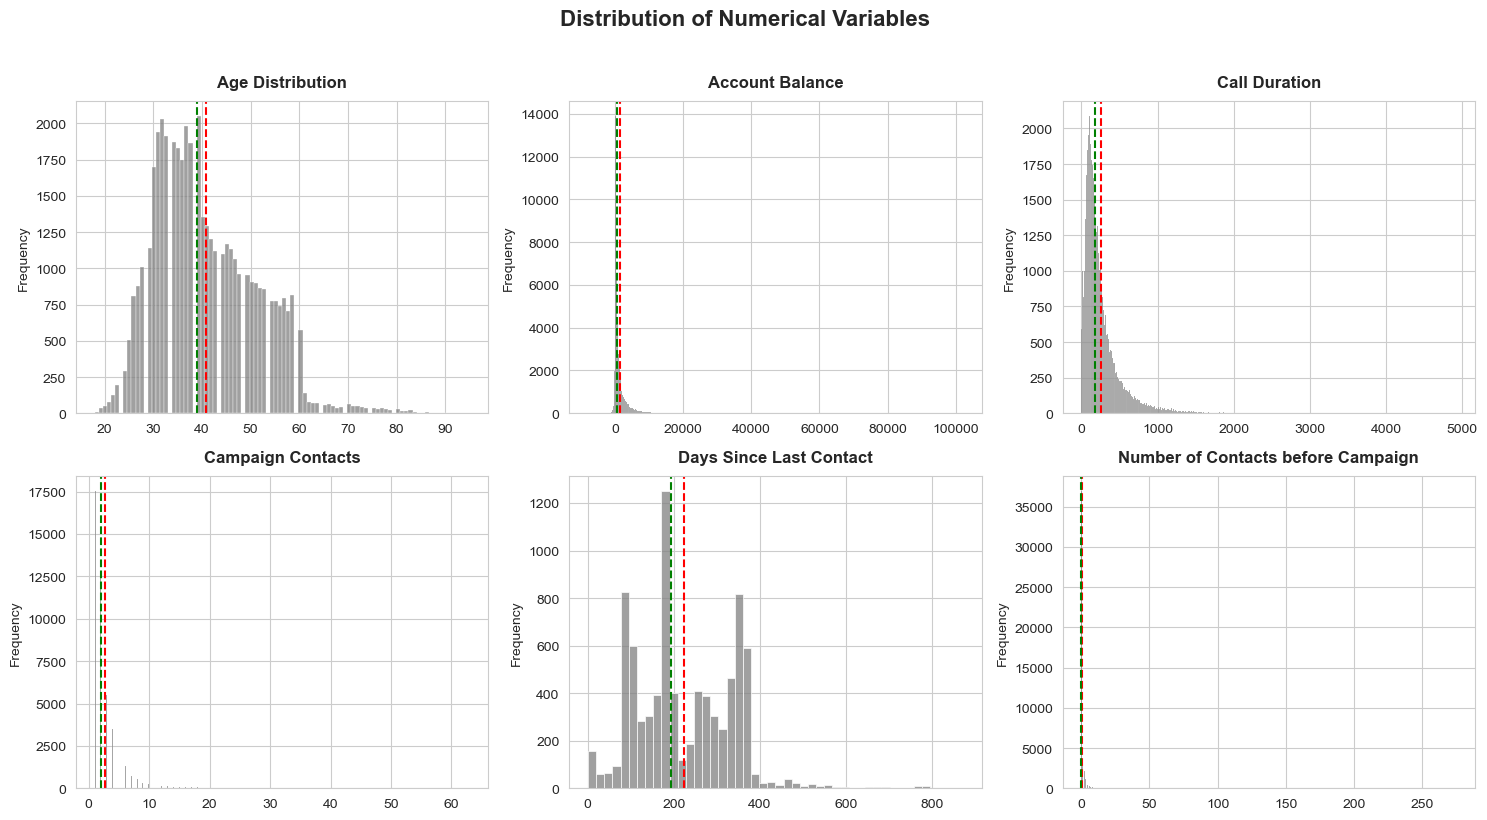

,age,balance,duration,campaign,effective_pdays,previous
mean,40.82,1362.27,258.16,2.76,224.58,0.58
median,39.00,448.00,180.00,2.00,194.00,0.00
std,10.45,3044.77,257.53,3.10,115.34,2.30
min,18.00,-8019.00,0.00,1.00,1.00,0.00
max,95.00,102127.00,4918.00,63.00,871.00,275.00
skew,0.72,8.36,3.14,4.90,0.69,41.85


In [10]:
# numerical columns to plot
numerical_cols = ['age', 'balance', 'duration', 'campaign', 'effective_pdays', 'previous']

# titles for each column
title_map = {
    'age': 'Age Distribution',
    'balance': 'Account Balance',
    'duration': 'Call Duration',
    'campaign': 'Campaign Contacts',
    'effective_pdays': 'Days Since Last Contact',
    'previous': 'Number of Contacts before Campaign'
}

# grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=bank_reduced_df, x=col, ax=axes[i],color='grey', kde=False)  # kde=True overlays a density curve
    # mean and median vertical lines
    axes[i].axvline(bank_reduced_df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(bank_reduced_df[col].median(), color='green', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_title(title_map.get(col, col.replace('_', ' ').title()), fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.show()

centrality = bank_reduced_df[numerical_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).round(2)
display(centrality)

### Findings
- `age` has a near-normal distribution shape with a longer tail toward older ages. Most clients are between 25 to 60 years old, with a fairly close mean and meadian of 41y and 39y respectively. 

- In contrast, `balance` is highly right-skewed variable, with values ranging from $-8019 \text{ €}$ to $\$ 102,127 \text{ €}$.

- Call `duration` is heavily right-skewed. Most calls are brief, with a median of 180 seconds, but some extend to very long durations of up to 4918 seconds. Although the mean and median are similar, the distribution shows most values cluster at $0$, with a long tail of longer calls.

- Similarly, `campaign` contacts is also strongly right-skewed. Most clients were contacted only 1 to 3 times, but in extreme cases, clients were contacted up to 63 times. 

- Days since last contact, `effective_pdays` shows a likely bimodal distribution and may be better visualized by dropping all `NaNs`

- Number of contacts made before this campaign `previous` is also heavily right-skewed. The distribution shows that some clients were never contacted before, while in some extreme cases, clients were contacted up to 250 times.

## Binary Variables 
The following charts display the distribution of binary variables in the dataset, each representing a yes/no characteristic of the client or their history with the bank.

In [11]:
# Class that allows to display multiple DataFrame side by side. (Source Pandas Notebook Module 3.)
from IPython.display import display, HTML

class display(object):
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self,*args):
        self.args = args
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                        for a in self.args)
    def __repr__(self):
        return'\n\n'.join(a + '\n' + repr(eval(a))
                        for a in self.args)

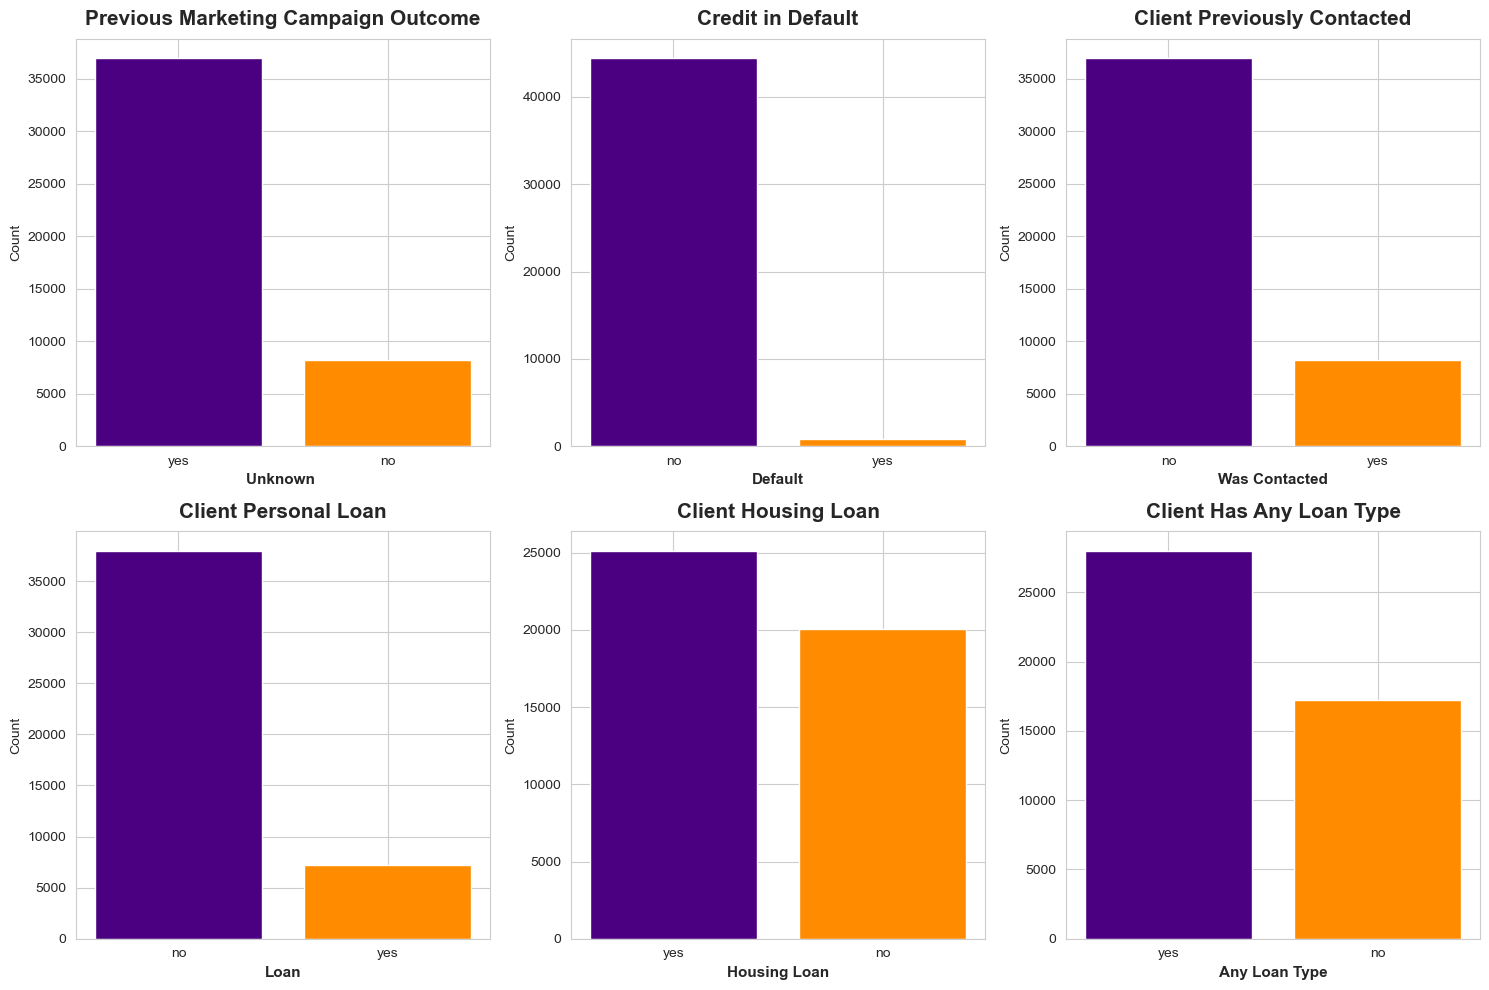

,unknown,count
0,yes,36959
1,no,8252
,default,count
0,no,44419
1,yes,792
,was contacted,count
0,no,36954
1,yes,8257
,loan,count
0,no,37967


In [12]:
# binary columns and labels
binary_cols = [
    {'col': 'poutcome_was_unknown', 'map': {0: 'no', 1: 'yes'}, 'title': 'Previous Marketing Campaign Outcome', 'xlabel': 'Unknown '},
    {'col': 'default',              'map': None,                  'title': 'Credit in Default',           'xlabel': 'Default'},
    {'col': 'was_previously_contacted', 'map': {0: 'no', 1: 'yes'}, 'title': 'Client Previously Contacted', 'xlabel': 'Was Contacted'},
    {'col': 'loan',                 'map': None,                  'title': 'Client Personal Loan',        'xlabel': 'Loan'},
    {'col': 'housing',              'map': None,                  'title': 'Client Housing Loan',         'xlabel': 'Housing Loan'},
    {'col': 'has_any_loan',         'map': {0: 'no', 1: 'yes'}, 'title': 'Client Has Any Loan Type',    'xlabel': 'Any Loan Type'},
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# store counts for display
count_dfs = {}

for i, config in enumerate(binary_cols):
    col = config['col']
    series = bank_reduced_df[col].map(config['map']) if config['map'] else bank_reduced_df[col]
    counts = series.value_counts()

    # barplots
    axes[i].bar(counts.index, counts.values, color=['indigo', 'darkorange'])
    axes[i].set_title(config['title'], fontsize=15, fontweight='bold', pad=10)
    axes[i].set_xlabel(config['xlabel'], fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    
    count_dfs[col] = counts.reset_index().set_axis([config['xlabel'].lower(), 'count'], axis=1)

poutcome_unknown = count_dfs['poutcome_was_unknown']
credit_in_default = count_dfs['default']
previous_contact = count_dfs['was_previously_contacted']
personal_loan = count_dfs['loan']
housing_loan = count_dfs['housing']
any_loan_type = count_dfs['has_any_loan']

plt.tight_layout()
plt.savefig('binary_variables_barchart.png')
plt.show()

# count display
display('poutcome_unknown', 'credit_in_default', 'previous_contact', 'personal_loan', 'housing_loan', 'any_loan_type')


### Findings


The **Previous Marketing Campaign** chart, for the `poutcome_was_unknown` variable, shows an unknown outcome for the vast majority of clients, with about 37,000 labeled as unknown. This suggests that most clients were either not part of a prior campaign or their results were not recorded.

Similarly, the **Client Previously Contacted**  chart, `was_previously_contacted` variable, follows an identical pattern with around 37,000 clients never contacted before and about 8,000 who were.

The **Credit in Default** chart for the `default` variable shows extreme class imbalance, with only 792 clients in default compared to 44,419 who are not, which represents less than 2% of the dataset. This could indicate very low predictive value, so excluding it from the model should be considered.

The **personal loan** chart for the `loan` variable is also imbalanced, with about 38,000 clients without a loan and 7,000 with one. However, both classes are sufficiently represented, so it remains useful for modeling.

In contrast, the **housing loan** chart is the most balanced, with 25,130 clients having a housing loan and 20,081 without, making `housing` a strong variable for the model. 

Additionally, the **Has Any Loan Type** chart shows that approximately 62% of clients have a loan, while 38% do not. The `has_any_loan` variable is a derived feature from personal and housing loans, which could make a valuable contribution to the model.


## Nominal Variables

The following charts display the distribution of categorical variables in the dataset, including clients' previous campaign outcomes, employment types, marital status, and contact communication method.

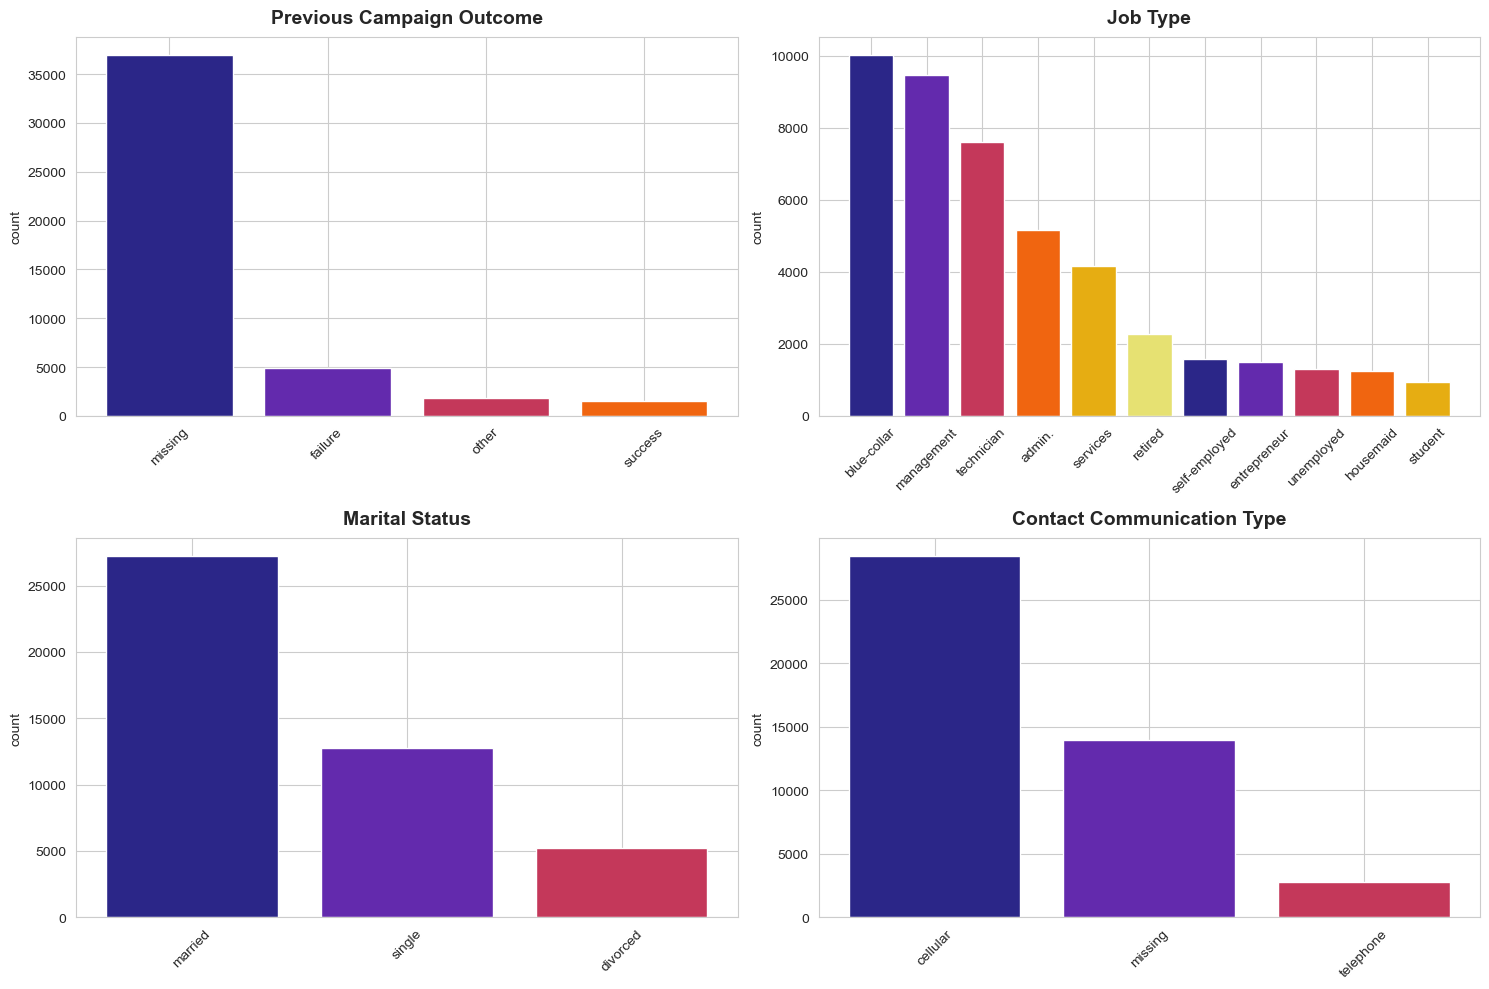

In [13]:
# Visualization of categorical variables
categorical_cols = ['poutcome', 'job', 'marital', 'contact']
title = {
    'poutcome':'Previous Campaign Outcome',
    'job':'Job Type',
    'marital':'Marital Status',
    'contact':'Contact Communication Type'
}

fig, axes = plt.subplots(2, 2,figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = bank_reduced_df[col].value_counts()
    colors = sns.color_palette(palette='CMRmap') # different color per bar   
    axes[i].bar(counts.index, counts.values, color = colors)
    axes[i].set_title(title[col], fontsize=14, fontweight='bold',pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=45)  # rotates label

plt.tight_layout()
plt.savefig('categorical_variables_barchart.png')
plt.show()